# Lab: Classification of Plants by Leaf Images

**Dataset:** [Kaggle — Leaf Classification](https://www.kaggle.com/competitions/leaf-classification)

**Goal:** Prepare image data for training an EfficientNet-B0 model in Edge Impulse.

What we need to do here in Google Colab:
1. Upload the dataset and resize all leaf images to 64×64 pixels
2. Apply data augmentation (rotation, contrast changes) since we only have ~10 images per class
3. Export everything in a format Edge Impulse can accept

Then in Edge Impulse we set up:
- Processing block: **Image (RGB)**
- Learning block: **Transfer Learning (EfficientNet-B0)**

In [3]:
# standard libraries for working with images and data
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import matplotlib.pyplot as plt

## Step 0 — Upload the dataset

I downloaded the zip from Kaggle manually (`leaf-classification.zip`, ~36 MB).
The cell below will ask to upload it if it hasn't been uploaded yet.

The Kaggle zip has nested zips inside (`train.csv.zip`, `images.zip`, etc.), so we need to extract twice.

In [4]:
from google.colab import files

DATA_DIR = "./leaf_data"
os.makedirs(DATA_DIR, exist_ok=True)

# check if we already have the csv (so we don't re-upload every time)
if not os.path.exists(os.path.join(DATA_DIR, "train.csv")):

    if not os.path.exists(os.path.join(DATA_DIR, "leaf-classification.zip")):
        print("Please upload leaf-classification.zip from Kaggle:")
        uploaded = files.upload()
        for fn, content in uploaded.items():
            with open(os.path.join(DATA_DIR, fn), "wb") as f:
                f.write(content)

    # extract the main zip
    main_zip = os.path.join(DATA_DIR, "leaf-classification.zip")
    if os.path.exists(main_zip):
        with zipfile.ZipFile(main_zip, "r") as zf:
            zf.extractall(DATA_DIR)

    # the main zip contains more zips inside, so extract those too
    for f in os.listdir(DATA_DIR):
        fpath = os.path.join(DATA_DIR, f)
        if f.endswith(".zip") and f != "leaf-classification.zip":
            with zipfile.ZipFile(fpath, "r") as zf:
                zf.extractall(DATA_DIR)
            print(f"Extracted: {f}")

# show what files we have now
print("\nFiles in data folder:")
for f in sorted(os.listdir(DATA_DIR)):
    if not f.endswith(".zip"):
        print(f"  {f}")

Please upload leaf-classification.zip from Kaggle:


Saving leaf-classification.zip to leaf-classification.zip
Extracted: train.csv.zip
Extracted: images.zip
Extracted: test.csv.zip
Extracted: sample_submission.csv.zip

Files in data folder:
  images
  sample_submission.csv
  test.csv
  train.csv


## Step 1 — Load the data and explore it a bit

Let's see what we're working with. The train.csv has the image IDs mapped to species names, and the actual images are in the `images/` folder as .jpg files.

In [5]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

print(f"Total training images: {len(train_df)}")
print(f"Number of species:     {train_df['species'].nunique()}")
print(f"Images per species:    {len(train_df) // train_df['species'].nunique()}")
print()
print("First few rows:")
train_df.head()

Total training images: 990
Number of species:     99
Images per species:    10

First few rows:


,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,1,Acer_Opalus,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,2,Pterocarya_Stenoptera,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,3,Quercus_Hartwissiana,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,5,Tilia_Tomentosa,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,6,Quercus_Variabilis,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


So we have 990 images across 99 species — that's only **10 images per class**. That's really not a lot, which is why augmentation will be important later.

Let's look at a few sample images to understand what they look like:

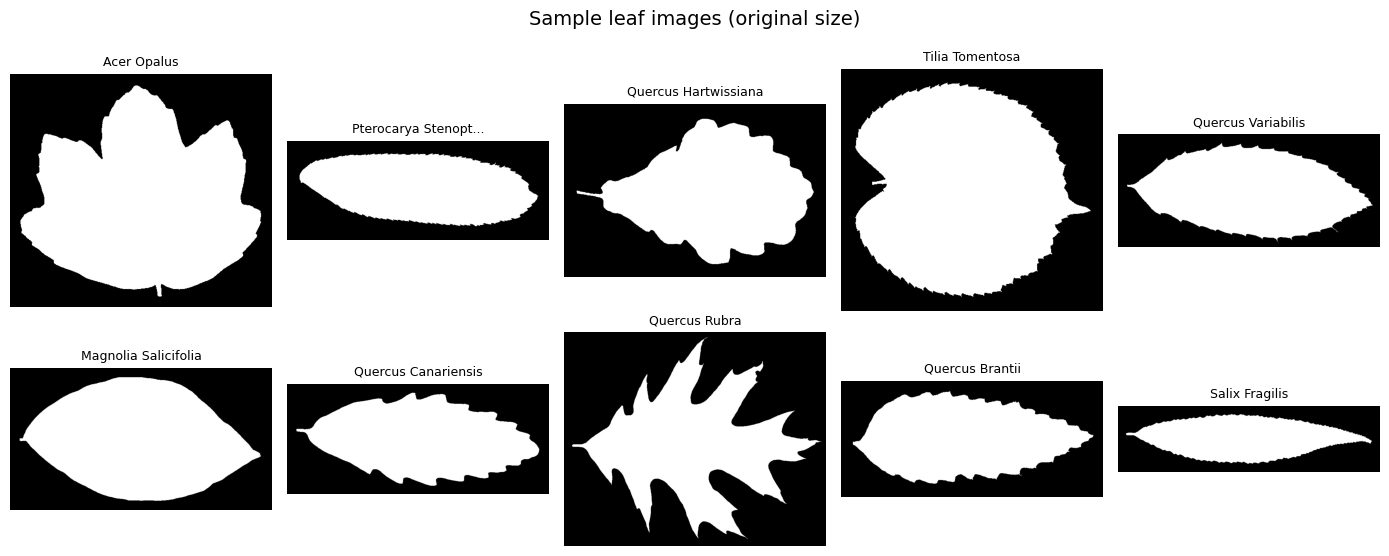

Found 50 different image sizes in first 50 images
Examples: [(671, 445), (733, 548), (1497, 203), (271, 548), (817, 319)]

This is why we need to resize everything to a consistent 64x64.


In [6]:
# find the images folder
img_source = os.path.join(DATA_DIR, "images")
if not os.path.isdir(img_source):
    img_source = DATA_DIR  # fallback

# show a grid of sample leaves from different species
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample leaf images (original size)", fontsize=14)

sample = train_df.drop_duplicates("species").head(10)
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img_path = os.path.join(img_source, f"{row['id']}.jpg")
    img = Image.open(img_path)
    ax.imshow(img, cmap="gray")
    # shorten the species name so it fits
    label = row['species'].replace('_', ' ')
    if len(label) > 20:
        label = label[:18] + '...'
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# check the original image sizes — they're not all the same
sample_sizes = []
for img_id in train_df['id'].head(50):
    img = Image.open(os.path.join(img_source, f"{img_id}.jpg"))
    sample_sizes.append(img.size)

unique_sizes = set(sample_sizes)
print(f"Found {len(unique_sizes)} different image sizes in first 50 images")
print("Examples:", list(unique_sizes)[:5])
print("\nThis is why we need to resize everything to a consistent 64x64.")

## Step 2 — Resize all images to 64×64

Edge Impulse needs a fixed input size. We're using 64×64 which is small enough to train quickly but still keeps enough detail for leaf shape recognition.

We'll organize images into folders by species name — this folder structure is what Edge Impulse uses to assign labels automatically.

In [7]:
IMG_DIR_64 = "./processed_64x64"
os.makedirs(IMG_DIR_64, exist_ok=True)

# map each image id to its species
id_to_species = dict(zip(train_df["id"], train_df["species"]))

resized_count = 0
missing = 0

for img_id, species in tqdm(id_to_species.items(), desc="Resizing to 64x64"):
    src_path = os.path.join(img_source, f"{img_id}.jpg")
    if not os.path.exists(src_path):
        missing += 1
        continue

    # create a folder for this species if it doesn't exist
    species_dir = os.path.join(IMG_DIR_64, species)
    os.makedirs(species_dir, exist_ok=True)

    # open, resize, and save
    img = Image.open(src_path).convert("RGB")
    img_resized = img.resize((64, 64), Image.LANCZOS)
    img_resized.save(os.path.join(species_dir, f"{img_id}.jpg"), quality=95)
    resized_count += 1

print(f"\nResized {resized_count} images")
if missing > 0:
    print(f"(couldn't find {missing} images)")

# quick check — how many per class?
class_counts = {}
for folder in sorted(os.listdir(IMG_DIR_64)):
    path = os.path.join(IMG_DIR_64, folder)
    if os.path.isdir(path):
        class_counts[folder] = len([f for f in os.listdir(path) if f.endswith(".jpg")])

print(f"Classes: {len(class_counts)}")
print(f"Images per class: min={min(class_counts.values())}, max={max(class_counts.values())}")

Resizing to 64x64: 100%|██████████| 990/990 [00:06<00:00, 151.95it/s]



Resized 990 images
Classes: 99
Images per class: min=10, max=10


Let's verify the resized images look okay:

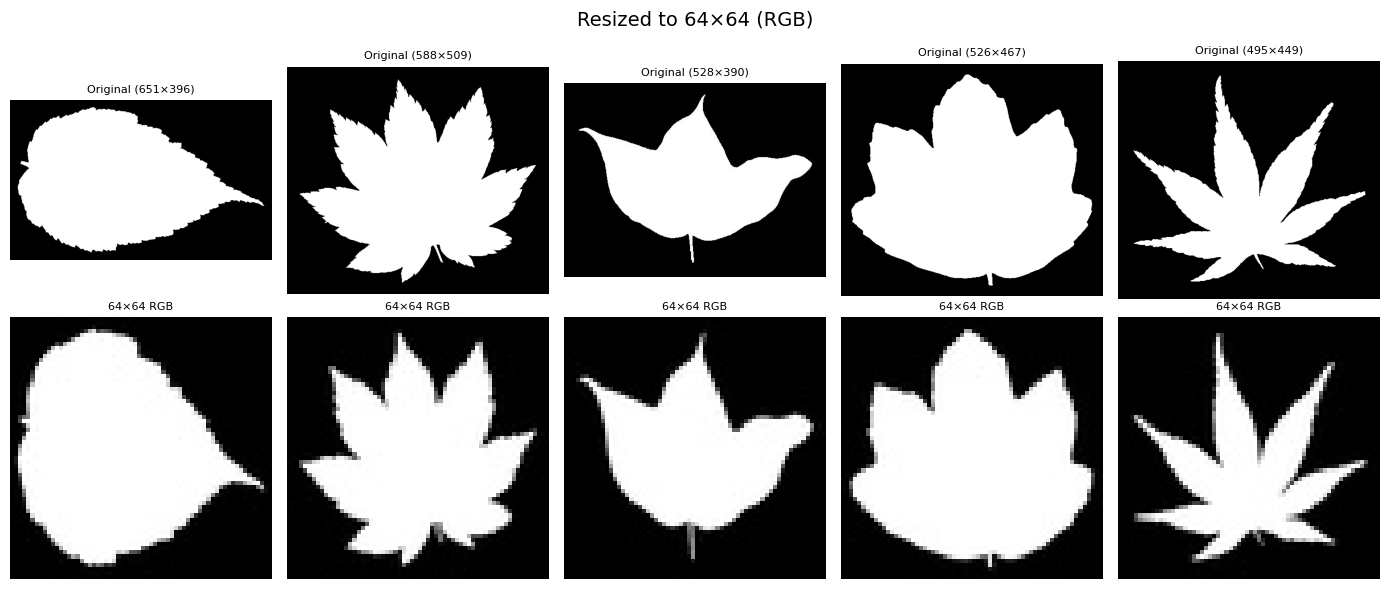

In [8]:
# show some before/after comparisons
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Resized to 64×64 (RGB)", fontsize=14)

sample_species = list(class_counts.keys())[:5]
for i, species in enumerate(sample_species):
    # original
    orig_id = train_df[train_df['species'] == species]['id'].iloc[0]
    orig = Image.open(os.path.join(img_source, f"{orig_id}.jpg"))
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f"Original ({orig.size[0]}×{orig.size[1]})", fontsize=8)
    axes[0, i].axis('off')

    # resized
    resized = Image.open(os.path.join(IMG_DIR_64, species, f"{orig_id}.jpg"))
    axes[1, i].imshow(resized)
    axes[1, i].set_title(f"64×64 RGB", fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Resized", fontsize=10)
plt.tight_layout()
plt.show()

## Step 3 — Data Augmentation

With only 10 images per class, the model would definitely overfit. We can artificially increase the dataset by creating modified copies of each image.

Each original image gets one augmented copy that combines two transformations at once:
- **Slight rotation (15°)** — leaves don't always sit perfectly straight, so a small tilt helps the model handle natural variation
- **Contrast boost (×1.3)** — simulates slightly different lighting conditions

By combining both into a single augmented image, we keep the dataset small while still introducing meaningful variation. This gives us **20 images per class** (10 original + 10 augmented = 1980 total).

The count is deliberately kept low so that training fits within Edge Impulse's free tier compute limit (1 hour).

In [9]:
AUG_DIR = "./augmented_64x64"

# clean previous augmentation if re-running
if os.path.exists(AUG_DIR):
    shutil.rmtree(AUG_DIR)
os.makedirs(AUG_DIR, exist_ok=True)

total_augmented = 0

for species_folder in tqdm(sorted(os.listdir(IMG_DIR_64)), desc="Augmenting"):
    src_dir = os.path.join(IMG_DIR_64, species_folder)
    dst_dir = os.path.join(AUG_DIR, species_folder)
    if not os.path.isdir(src_dir):
        continue

    os.makedirs(dst_dir, exist_ok=True)

    originals = [f for f in os.listdir(src_dir) if f.endswith(".jpg")]

    # copy originals first
    for f in originals:
        shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

    # one augmentation per image: slight rotation + contrast boost
    aug_count = 0
    for f in originals:
        img = Image.open(os.path.join(src_dir, f)).convert("RGB")
        base_name = os.path.splitext(f)[0]

        rotated = img.rotate(15, expand=False, fillcolor=(0, 0, 0))
        enhanced = ImageEnhance.Contrast(rotated).enhance(1.3)
        enhanced.save(os.path.join(dst_dir, f"{base_name}_aug.jpg"), quality=95)
        aug_count += 1

    total_augmented += aug_count

total_all = sum(
    len([f for f in os.listdir(os.path.join(AUG_DIR, d)) if f.endswith(".jpg")])
    for d in os.listdir(AUG_DIR) if os.path.isdir(os.path.join(AUG_DIR, d))
)

print(f"\nAugmented images created: {total_augmented}")
print(f"Total images now: {total_all}")
print(f"Per class: {total_all // 99}")

Let's visualize what the augmentations look like for one sample leaf:

In [10]:
# pick one species and show original vs augmented
species_list = sorted(
    [d for d in os.listdir(AUG_DIR) if os.path.isdir(os.path.join(AUG_DIR, d))]
)

if not species_list:
    raise RuntimeError("No augmented folders found. Run Step 3 first.")

example_species = species_list[0]
example_dir = os.path.join(AUG_DIR, example_species)
example_files = sorted(os.listdir(example_dir))[:6]  # show first 6

fig, axes = plt.subplots(1, min(6, len(example_files)), figsize=(14, 3))
fig.suptitle(f"Augmentation examples — {example_species.replace('_', ' ')}", fontsize=12)

for ax, fname in zip(axes, example_files):
    img = Image.open(os.path.join(example_dir, fname))
    ax.imshow(img)
    label = "rot 15° + contrast" if "_aug" in fname else "original"
    ax.set_title(label, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 4 — Export for Edge Impulse

Edge Impulse can import data in a folder-per-label structure:

```text
training/
  species_a/
    species_a.0001.jpg
    species_a.0002.jpg
testing/
  species_a/
    species_a.0001.jpg
```

We split the augmented data 80/20 into training and testing sets, then copy the files into
label folders. While copying, each file is renamed to the Edge Impulse-friendly format:

`<label>.<number>.jpg`

That way:
- the **folder name** is a valid label, and
- the **filename** is also valid if Edge Impulse reads labels from the file name.

In [11]:
from sklearn.model_selection import train_test_split
import re

EDGE_EXPORT = "./edge_impulse_export"

# clean previous export if re-running
if os.path.exists(EDGE_EXPORT):
    shutil.rmtree(EDGE_EXPORT)

ei_training = os.path.join(EDGE_EXPORT, "training")
ei_testing  = os.path.join(EDGE_EXPORT, "testing")
os.makedirs(ei_training, exist_ok=True)
os.makedirs(ei_testing, exist_ok=True)

def safe_label(label: str) -> str:
    # keep labels simple for Edge Impulse
    return re.sub(r"[^A-Za-z0-9_-]+", "_", label.strip())

train_count = 0
test_count = 0

for species_folder in tqdm(sorted(os.listdir(AUG_DIR)), desc="Splitting train/test"):
    src_dir = os.path.join(AUG_DIR, species_folder)
    if not os.path.isdir(src_dir):
        continue

    all_images = sorted([f for f in os.listdir(src_dir) if f.lower().endswith(".jpg")])

    # 80% training, 20% testing
    if len(all_images) >= 5:
        tr_imgs, te_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
        tr_imgs = sorted(tr_imgs)
        te_imgs = sorted(te_imgs)
    else:
        tr_imgs = all_images
        te_imgs = []

    label = safe_label(species_folder)

    # copy to training folder with Edge Impulse-friendly names
    tr_dir = os.path.join(ei_training, label)
    os.makedirs(tr_dir, exist_ok=True)
    for idx, f in enumerate(tr_imgs, start=1):
        ext = os.path.splitext(f)[1].lower() or ".jpg"
        new_name = f"{label}.{idx:04d}{ext}"
        shutil.copy2(os.path.join(src_dir, f), os.path.join(tr_dir, new_name))
        train_count += 1

    # copy to testing folder with Edge Impulse-friendly names
    te_dir = os.path.join(ei_testing, label)
    os.makedirs(te_dir, exist_ok=True)
    for idx, f in enumerate(te_imgs, start=1):
        ext = os.path.splitext(f)[1].lower() or ".jpg"
        new_name = f"{label}.{idx:04d}{ext}"
        shutil.copy2(os.path.join(src_dir, f), os.path.join(te_dir, new_name))
        test_count += 1

print(f"\nTraining images: {train_count}")
print(f"Testing images:  {test_count}")
total_count = train_count + test_count
if total_count:
    print(f"Split ratio:     {train_count/total_count*100:.0f}% / {test_count/total_count*100:.0f}%")

# show a quick example of the exported names
example_labels = sorted([d for d in os.listdir(ei_training) if os.path.isdir(os.path.join(ei_training, d))])
if example_labels:
    example_label = example_labels[0]
    example_files = sorted(os.listdir(os.path.join(ei_training, example_label)))[:5]
    print(f"\nExample label folder: {example_label}")
    print("Example files:")
    for name in example_files:
        print(f"  {name}")

In [12]:
# zip everything up and download to your computer
print("Creating zip files...")

shutil.make_archive("ei_training", "zip", ei_training)
print(f"  ei_training.zip — {os.path.getsize('ei_training.zip') / 1e6:.1f} MB")

shutil.make_archive("ei_testing", "zip", ei_testing)
print(f"  ei_testing.zip  — {os.path.getsize('ei_testing.zip') / 1e6:.1f} MB")

# download both zips
files.download("ei_training.zip")
files.download("ei_testing.zip")

print("\nDone! Upload BOTH zip files in Edge Impulse:")
print("  1) ei_training.zip -> Training data")
print("  2) ei_testing.zip  -> Testing data")

## Summary

| Step | Result |
|------|--------|
| Original dataset | 990 images, 99 species, ~10 per class |
| After resize | 990 images at 64×64 RGB |
| After augmentation | ~1980 images (20 per class) |
| Training set | ~1584 images (80%) |
| Testing set | ~396 images (20%) |

### Next: Edge Impulse setup

1. Create a new project at [studio.edgeimpulse.com](https://studio.edgeimpulse.com)
2. **Data Acquisition** → Upload `ei_training.zip` as Training, `ei_testing.zip` as Testing
3. **Create Impulse:**
   - Image data: 64×64
   - Processing block: **Image (RGB)**
   - Learning block: **Transfer Learning (EfficientNet-B0)**
4. **Image** tab → Save parameters → Generate features
5. **Transfer Learning** tab → set training cycles to 50–100, learning rate 0.001 → Start training